In [133]:
#Data simulation

In [134]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_users = 1_000_000

df = pd.DataFrame({
    "user_id": np.arange(1, n_users + 1),

    # Engagement features
    "active_days_7d": np.random.poisson(lam=3.2, size=n_users).clip(0, 7),
    "lessons_completed_7d": np.random.poisson(lam=5.5, size=n_users).clip(0, 30),
    "avg_session_minutes": np.random.gamma(shape=2.2, scale=8, size=n_users).clip(1, 120),

    # Risk/friction features
    "days_since_last_active": np.random.exponential(scale=3.5, size=n_users).clip(0, 30),
    "support_tickets_30d": np.random.poisson(lam=0.35, size=n_users).clip(0, 8)
})

df.head()

,user_id,active_days_7d,lessons_completed_7d,avg_session_minutes,days_since_last_active,support_tickets_30d
0,1,4,4,8.349517,7.083256,0
1,2,1,9,12.825737,2.106535,1
2,3,3,2,17.030714,0.108584,2
3,4,3,5,15.706925,2.463970,0
4,5,2,3,22.385110,3.157960,0


In [135]:
# Create a latent churn risk score
logit = (
    -3.0
    - 0.35 * df["active_days_7d"]
    - 0.08 * df["lessons_completed_7d"]
    - 0.025 * df["avg_session_minutes"]
    + 0.22 * df["days_since_last_active"]
    + 0.45 * df["support_tickets_30d"]
)

# Convert logit to probability
df["churn_probability"] = 1 / (1 + np.exp(-logit))

# Generate churn target
df["churn_14d"] = np.random.binomial(1, df["churn_probability"])

df["churn_14d"].value_counts(normalize=True)

,proportion
churn_14d,
0,0.969241
1,0.030759


In [136]:
churn_rate = df["churn_14d"].mean()

print(f"Churn rate: {churn_rate:.2%}")
print(df["churn_14d"].value_counts())

Churn rate: 3.08%
churn_14d
0    969241
1     30759
Name: count, dtype: int64


#Our data set has 3% churners out of 1M Users, Simulated the data set by keeping it imbalanced intentionally

In [137]:
!pip install xgboost imbalanced-learn shap -q

In [138]:
from sklearn.model_selection import train_test_split

features = [
    "active_days_7d",
    "lessons_completed_7d",
    "avg_session_minutes",
    "days_since_last_active",
    "support_tickets_30d"
]

X = df[features]
y = df["churn_14d"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train churn rate: 0.030758666666666667
Test churn rate: 0.03076


#Base line XG Boost without SMOTE

In [139]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, baseline_probs))
print("PR-AUC:", average_precision_score(y_test, baseline_probs))

ROC-AUC: 0.7939895771298349
PR-AUC: 0.21122162950850445


#SMOTE ON Training Data

In [140]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.35)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts(normalize=True))
print(y_train_smote.value_counts(normalize=True))

churn_14d
0    0.969241
1    0.030759
Name: proportion, dtype: float64
churn_14d
0    0.740741
1    0.259259
Name: proportion, dtype: float64


#Evaluating SMOTE for imbalance handling

In [141]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("PR-AUC:", average_precision_score(y_test, xgb_probs))

ROC-AUC: 0.7879547824770029
PR-AUC: 0.20816457974770977


#Choosing multiple thresholds and evaluation the model efficacy

In [142]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "flagged_users": preds.sum(),
        "flagged_rate": preds.mean()
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,f1,flagged_users,flagged_rate
0,0.2,0.063349,0.762289,0.116977,92535,0.370140
1,0.3,0.095534,0.608062,0.165125,48946,0.195784
2,0.4,0.134231,0.482185,0.210002,27624,0.110496
3,0.5,0.179518,0.382965,0.244449,16405,0.065620
4,0.6,0.237133,0.300780,0.265191,9754,0.039016
5,0.7,0.310257,0.222627,0.259237,5518,0.022072


#Rough business impact of a churned user

In [143]:
monthly_subscription = 10
expected_remaining_months = 24

gross_ltv_per_user = monthly_subscription * expected_remaining_months

actual_churners = df["churn_14d"].sum()
total_users = len(df)

gross_ltv_at_risk = actual_churners * gross_ltv_per_user

print(f"Total users: {total_users:,}")
print(f"Actual churners: {actual_churners:,}")
print(f"Gross LTV per user: ${gross_ltv_per_user:,.0f}")
print(f"Gross LTV at risk: ${gross_ltv_at_risk:,.0f}")

Total users: 1,000,000
Actual churners: 30,759
Gross LTV per user: $240
Gross LTV at risk: $7,382,160


#Net LTV

In [144]:
gross_margin = 0.75

net_ltv_per_user = gross_ltv_per_user * gross_margin
net_ltv_at_risk = actual_churners * net_ltv_per_user

print(f"Net contribution LTV per user: ${net_ltv_per_user:,.0f}")
print(f"Net contribution at risk: ${net_ltv_at_risk:,.0f}")

Net contribution LTV per user: $180
Net contribution at risk: $5,536,620


##With a dollar 10 monthly subscription and an assumed 24-month remaining customer life, each churned user represents approximately 240dollars for next 2 years in gross LTV. At a 3.1% churn rate across 1M users, the churn cohort represents $7.38M in gross LTV at risk, or 5.54M dollars in contribution value assuming a 75% gross margin

#lets check the model efficacy various thresholds before choosing a single threshold

In [145]:
# Thresholds to evaluate
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

# Business assumptions
monthly_subscription = 10
expected_remaining_months = 24
gross_margin = 0.75
intervention_cost_per_user = 8
expected_save_rate = 0.20

gross_ltv_per_user = monthly_subscription * expected_remaining_months
net_ltv_per_user = gross_ltv_per_user * gross_margin

confusion_results = []

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    flagged_users = tp + fp
    missed_churners = fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else np.nan
    )

    ltv_risk_identified = tp * net_ltv_per_user
    missed_ltv_risk = fn * net_ltv_per_user
    expected_saved_ltv = tp * net_ltv_per_user * expected_save_rate
    intervention_cost = flagged_users * intervention_cost_per_user
    expected_net_value = expected_saved_ltv - intervention_cost

    value_per_flagged_user = (
        expected_net_value / flagged_users if flagged_users > 0 else np.nan
    )

    confusion_results.append({
        "threshold": t,
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "flagged_users": flagged_users,
        "flagged_rate": flagged_users / len(y_test),
        "missed_churners": missed_churners,
        "ltv_risk_identified": ltv_risk_identified,
        "missed_ltv_risk": missed_ltv_risk,
        "expected_saved_ltv": expected_saved_ltv,
        "intervention_cost": intervention_cost,
        "expected_net_value": expected_net_value,
        "value_per_flagged_user": value_per_flagged_user
    })

business_threshold_df = pd.DataFrame(confusion_results)

# Cleaner formatting for display
display_df = business_threshold_df.copy()

money_cols = [
    "ltv_risk_identified",
    "missed_ltv_risk",
    "expected_saved_ltv",
    "intervention_cost",
    "expected_net_value",
    "value_per_flagged_user"
]

for col in money_cols:
    display_df[col] = display_df[col].map(lambda x: f"${x:,.0f}")

rate_cols = ["precision", "recall", "f1", "flagged_rate"]

for col in rate_cols:
    display_df[col] = display_df[col].map(lambda x: f"{x:.2%}")

display_df

,threshold,true_positives,false_positives,true_negatives,false_negatives,precision,recall,f1,flagged_users,flagged_rate,missed_churners,ltv_risk_identified,missed_ltv_risk,expected_saved_ltv,intervention_cost,expected_net_value,value_per_flagged_user
0,0.2,5862,86673,155637,1828,6.33%,76.23%,11.70%,92535,37.01%,1828,"$1,055,160","$329,040","$211,032","$740,280","$-529,248",$-6
1,0.3,4676,44270,198040,3014,9.55%,60.81%,16.51%,48946,19.58%,3014,"$841,680","$542,520","$168,336","$391,568","$-223,232",$-5
2,0.4,3708,23916,218394,3982,13.42%,48.22%,21.00%,27624,11.05%,3982,"$667,440","$716,760","$133,488","$220,992","$-87,504",$-3
3,0.5,2945,13460,228850,4745,17.95%,38.30%,24.44%,16405,6.56%,4745,"$530,100","$854,100","$106,020","$131,240","$-25,220",$-2
4,0.6,2313,7441,234869,5377,23.71%,30.08%,26.52%,9754,3.90%,5377,"$416,340","$967,860","$83,268","$78,032","$5,236",$1
5,0.7,1712,3806,238504,5978,31.03%,22.26%,25.92%,5518,2.21%,5978,"$308,160","$1,076,040","$61,632","$44,144","$17,488",$3


In [146]:
business_threshold_df.sort_values("expected_net_value", ascending=False)[
    [
        "threshold",
        "precision",
        "recall",
        "flagged_users",
        "expected_net_value",
        "value_per_flagged_user",
        "missed_ltv_risk"
    ]
]

,threshold,precision,recall,flagged_users,expected_net_value,value_per_flagged_user,missed_ltv_risk
5,0.7,0.310257,0.222627,5518,17488.0,3.169264,1076040.0
4,0.6,0.237133,0.300780,9754,5236.0,0.536805,967860.0
3,0.5,0.179518,0.382965,16405,-25220.0,-1.537336,854100.0
2,0.4,0.134231,0.482185,27624,-87504.0,-3.167680,716760.0
1,0.3,0.095534,0.608062,48946,-223232.0,-4.560781,542520.0
0,0.2,0.063349,0.762289,92535,-529248.0,-5.719436,329040.0


#Although lower thresholds captured more churners, they created large false-positive contact volumes and negative expected value. A 0.70 threshold was selected for the pilot because it produced the strongest precision and expected value per contacted user, making it suitable for a controlled retention experiment. Lower thresholds may be reconsidered if intervention costs fall or expected save rates improve.

In [147]:
import shap
import matplotlib.pyplot as plt

# Use a sample for SHAP because 1M rows can be heavy
X_shap = X_test.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

/tmp/ipykernel_511/1316841741.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap)


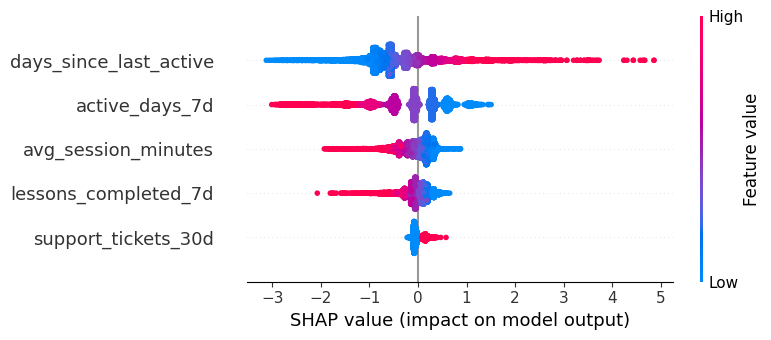

In [148]:
shap.summary_plot(shap_values, X_shap)

#SHAP analysis showed that recency and engagement signals were the strongest predictors of churn risk. Higher inactivity and support friction increased predicted churn risk, while stronger weekly activity, lesson completion, and longer sessions reduced predicted risk. These patterns were used to design retention actions, but were not treated as causal proof.

#creating the intervention data set to flag users at risk

In [149]:
chosen_threshold = 0.70

experiment_df = X_test.copy()
experiment_df["actual_churn_pre_intervention"] = y_test.values
experiment_df["churn_probability"] = xgb_probs
experiment_df["high_risk_flag"] = (experiment_df["churn_probability"] >= chosen_threshold).astype(int)

high_risk_df = experiment_df[experiment_df["high_risk_flag"] == 1].copy()

print("High-risk users:", len(high_risk_df))
print("Pre-intervention churn rate:", high_risk_df["actual_churn_pre_intervention"].mean())

High-risk users: 5518
Pre-intervention churn rate: 0.3102573396158028


#Note: From here down this is a synthetic testbed, not a real experiment. I impose the treatment effect and guardrail effects myself, so the significance tests below are expected by construction. The point is to demonstrate the experiment-analysis and guardrail-decisioning pipeline — SRM check, two-proportion z-test, CI, guardrail significance — not to claim a discovered causal effect.

#The RCT was intentionally conducted only on users flagged at the 0.70 threshold because this represented the actionable target population for the retention campaign. The experiment estimates the causal impact of nudges within the high-risk segment, not across the full user base.

#Simulation Randomised control experiment

In [150]:
np.random.seed(42)

high_risk_df["experiment_group"] = np.random.choice(
    ["control", "treatment"],
    size=len(high_risk_df),
    p=[0.5, 0.5]
)

high_risk_df["experiment_group"].value_counts()

,count
experiment_group,
control,2769
treatment,2749


#SRM CHECKS

In [151]:
from scipy.stats import chisquare

group_counts = high_risk_df["experiment_group"].value_counts()

observed = np.array([
    group_counts["control"],
    group_counts["treatment"]
])

expected = np.array([
    len(high_risk_df) / 2,
    len(high_risk_df) / 2
])

srm_stat, srm_pvalue = chisquare(f_obs=observed, f_exp=expected)

print("Observed:", observed)
print("Expected:", expected)
print("SRM chi-square statistic:", srm_stat)
print("SRM p-value:", srm_pvalue)

Observed: [2769 2749]
Expected: [2759. 2759.]
SRM chi-square statistic: 0.07249003262051468
SRM p-value: 0.7877452079602815


#lets just assume treatment reduces churn probability by 12% relative

In [152]:
# Simulate retention experiment using observed high-risk churn rate
rng = np.random.default_rng(42)

treatment_effect = 0.12

base_churn_rate = high_risk_df["actual_churn_pre_intervention"].mean()

print(f"Observed high-risk churn rate: {base_churn_rate:.2%}")

# Start everyone at the observed high-risk churn rate
high_risk_df["post_intervention_churn_probability"] = base_churn_rate

# Apply 12% relative churn reduction only to treatment group
high_risk_df.loc[
    high_risk_df["experiment_group"] == "treatment",
    "post_intervention_churn_probability"
] = base_churn_rate * (1 - treatment_effect)

# Sanity check probabilities before simulation
prob_check = high_risk_df.groupby("experiment_group")[
    "post_intervention_churn_probability"
].agg(["count", "mean", "min", "max"])

display(prob_check)

# Simulate actual churn/no-churn outcome row by row
high_risk_df["post_intervention_churn"] = [
    rng.binomial(1, p)
    for p in high_risk_df["post_intervention_churn_probability"].astype(float)
]

# Sanity check actual 0/1 outcomes
display(
    high_risk_df.groupby("experiment_group")[
        "post_intervention_churn"
    ].value_counts()
)

# Check simulated churn rates
experiment_summary = high_risk_df.groupby("experiment_group").agg(
    users=("post_intervention_churn", "count"),
    churn_rate=("post_intervention_churn", "mean"),
    avg_predicted_risk=("churn_probability", "mean")
)

display(experiment_summary)

Observed high-risk churn rate: 31.03%


,count,mean,min,max
experiment_group,,,,
control,2769,0.310257,0.310257,0.310257
treatment,2749,0.273026,0.273026,0.273026


experiment_group  post_intervention_churn
control           0                          1949
                  1                           820
treatment         0                          2002
                  1                           747
Name: count, dtype: int64

,users,churn_rate,avg_predicted_risk
experiment_group,,,
control,2769,0.296136,0.811881
treatment,2749,0.271735,0.811441


#two-proportion z-test

In [153]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

summary = high_risk_df.groupby("experiment_group")["post_intervention_churn"].agg(["sum", "count", "mean"])

control_churns = summary.loc["control", "sum"]
control_n = summary.loc["control", "count"]
control_rate = summary.loc["control", "mean"]

treatment_churns = summary.loc["treatment", "sum"]
treatment_n = summary.loc["treatment", "count"]
treatment_rate = summary.loc["treatment", "mean"]

count = np.array([treatment_churns, control_churns])
nobs = np.array([treatment_n, control_n])

z_stat, p_value = proportions_ztest(count, nobs, alternative="smaller")

abs_lift = treatment_rate - control_rate
relative_lift = (treatment_rate - control_rate) / control_rate

ci_low, ci_high = confint_proportions_2indep(
    count1=treatment_churns,
    nobs1=treatment_n,
    count2=control_churns,
    nobs2=control_n,
    method="wald"
)

print(f"Control churn rate: {control_rate:.2%}")
print(f"Treatment churn rate: {treatment_rate:.2%}")
print(f"Absolute difference: {abs_lift:.2%}")
print(f"Relative difference: {relative_lift:.2%}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"95% CI for treatment-control difference: [{ci_low:.2%}, {ci_high:.2%}]")

Control churn rate: 29.61%
Treatment churn rate: 27.17%
Absolute difference: -2.44%
Relative difference: -8.24%
Z-statistic: -2.010
P-value: 0.02223
95% CI for treatment-control difference: [-4.82%, -0.06%]


#Experiment Result Interpretation

#The simulated retention nudge reduced churn among model-flagged high-risk users from 29.61% in the control group to 27.17% in the treatment group.

#This represents a 2.44 percentage-point absolute reduction and an 8.24% relative reduction in churn. The two-proportion z-test produced a p-value of 0.022, suggesting the reduction is statistically significant at the 5% level.

#The 95% confidence interval for the treatment-control difference was [-4.82%, -0.06%]. Since the full interval is below zero, the result suggests a positive treatment effect, but the effect is modest and close to the boundary of statistical significance.

#Because this is a synthetic experiment where the treatment effect was imposed by design, the result should be interpreted as a demonstration of the experimentation workflow rather than evidence of a real causal effect.

#Now lets, question is it worth doing financially

In [154]:
# Business assumptions
monthly_subscription = 10
expected_remaining_months = 24
gross_margin = 0.75
discount = 8

gross_ltv_per_user = monthly_subscription * expected_remaining_months
net_ltv_per_user = gross_ltv_per_user * gross_margin

# Experimental effect
incremental_retained_users = (control_rate - treatment_rate) * treatment_n

incremental_ltv_saved = incremental_retained_users * net_ltv_per_user
discount = treatment_n * intervention_cost_per_user
net_incremental_value = incremental_ltv_saved - discount

roi = net_incremental_value / discount

print(f"Treatment users: {treatment_n:,}")
print(f"Control churn rate: {control_rate:.2%}")
print(f"Treatment churn rate: {treatment_rate:.2%}")
print(f"Absolute churn reduction: {(control_rate - treatment_rate):.2%}")
print(f"Incremental retained users: {incremental_retained_users:,.0f}")
print(f"Net LTV per retained user: ${net_ltv_per_user:,.0f}")
print(f"Incremental LTV saved: ${incremental_ltv_saved:,.0f}")
print(f"discount: ${discount:,.0f}")
print(f"Net incremental value: ${net_incremental_value:,.0f}")
print(f"ROI: {roi:.2f}x")

Treatment users: 2,749
Control churn rate: 29.61%
Treatment churn rate: 27.17%
Absolute churn reduction: 2.44%
Incremental retained users: 67
Net LTV per retained user: $180
Incremental LTV saved: $12,074
discount: $21,992
Net incremental value: $-9,918
ROI: -0.45x


#Intervention assumption: each treated high-risk user received an 8dollars retention discount.

### Business Impact Interpretation

The retention nudge produced a statistically significant churn reduction, but the effect was not large enough to offset campaign cost under the current assumptions.

The treatment group included 2,749 high-risk users. Churn declined from 29.61% in control to 27.17% in treatment, creating an estimated 67 incremental retained users. Using a net contribution LTV of 180 per retained user, this translated into approximately 12.1K in incremental LTV saved.

However, the discount was approximately 22.0K, based on an 8 dollars cost per user. After subtracting discount cost, the net incremental value was -9.9K, with an ROI of -0.45x.

This means the campaign showed statistical success but not business success. The recommendation is not to scale the intervention as-is. The next iteration should either reduce campaign cost, improve treatment lift, or target an even higher-intent/high-risk segment before rollout.

#Simulating gaurdrails cause why stop at the north star metric "churn"

In [155]:
rng = np.random.default_rng(42)  # one rng, used for everything in this cell

high_risk_df["unsubscribe"] = np.where(
    high_risk_df["experiment_group"] == "treatment",
    rng.binomial(1, 0.035, len(high_risk_df)),
    rng.binomial(1, 0.020, len(high_risk_df))
)

high_risk_df["support_complaint"] = np.where(
    high_risk_df["experiment_group"] == "treatment",
    rng.binomial(1, 0.025, len(high_risk_df)),
    rng.binomial(1, 0.018, len(high_risk_df))
)

high_risk_df["discount_redeemed"] = np.where(
    high_risk_df["experiment_group"] == "treatment",
    rng.binomial(1, 0.28, len(high_risk_df)),
    0
)

high_risk_df["sessions_next_7d"] = np.where(
    high_risk_df["experiment_group"] == "treatment",
    rng.poisson(2.8, len(high_risk_df)),
    rng.poisson(2.3, len(high_risk_df))
)

In [156]:
guardrail_summary = high_risk_df.groupby("experiment_group").agg(
    users=("post_intervention_churn", "count"),
    churn_rate=("post_intervention_churn", "mean"),
    unsubscribe_rate=("unsubscribe", "mean"),
    support_complaint_rate=("support_complaint", "mean"),
    discount_redemption_rate=("discount_redeemed", "mean"),
    avg_sessions_next_7d=("sessions_next_7d", "mean")
)

guardrail_summary

,users,churn_rate,unsubscribe_rate,support_complaint_rate,discount_redemption_rate,avg_sessions_next_7d
experiment_group,,,,,,
control,2769,0.296136,0.023474,0.022391,0.000000,2.314193
treatment,2749,0.271735,0.037104,0.021099,0.292106,2.823208


#Well, there is a difference ofcourse. Is the difference statistically different or due to random noise?

In [157]:
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

def prop_test(metric):
    summary = high_risk_df.groupby("experiment_group")[metric].agg(["sum", "count"])

    treatment_sum = summary.loc["treatment", "sum"]
    treatment_n = summary.loc["treatment", "count"]

    control_sum = summary.loc["control", "sum"]
    control_n = summary.loc["control", "count"]

    z, p = proportions_ztest(
        count=np.array([treatment_sum, control_sum]),
        nobs=np.array([treatment_n, control_n])
    )

    return z, p

for metric in ["unsubscribe", "support_complaint", "discount_redeemed"]:
    z, p = prop_test(metric)
    print(f"{metric}: z={z:.3f}, p={p:.5f}")

treatment_sessions = high_risk_df.loc[
    high_risk_df["experiment_group"] == "treatment",
    "sessions_next_7d"
]

control_sessions = high_risk_df.loc[
    high_risk_df["experiment_group"] == "control",
    "sessions_next_7d"
]

t_stat, p_val = ttest_ind(treatment_sessions, control_sessions, equal_var=False)

print(f"sessions_next_7d: t={t_stat:.3f}, p={p_val:.5f}")

unsubscribe: z=2.955, p=0.00313
support_complaint: z=-0.329, p=0.74212
discount_redeemed: z=30.767, p=0.00000
sessions_next_7d: t=11.854, p=0.00000


# Guardrail Interpretation

#The intervention reduced churn and increased engagement, but it also created a measurable unsubscribe tradeoff.

#Treatment users had a lower churn rate than control, declining from 29.61% to 27.17%. Average next-week sessions also increased from 2.31 to 2.82, and this lift was statistically significant.

#However, unsubscribe rate increased from 2.35% in control to 3.71% in treatment, an incremental increase of 1.36 percentage points. The unsubscribe difference was statistically significant with p = 0.003, suggesting the retention discount created some customer-contact fatigue. Support complaints did not increase significantly, with p = 0.742.

#Discount redemption was 29.2% in treatment and 0% in control, which is expected because only treated users received the discount. This should be interpreted as a discount usage and margin-impact metric, not as a meaningful statistical guardrail test.

#Overall, the intervention improved churn and engagement, but the business impact remained negative after discount cost and unsubscribe-risk adjustment. The recommendation is not to scale the discount offer as-is. A better next test would compare lower-cost interventions such as in-app nudges, personalized progress reminders, frequency caps, or smaller targeted discounts.

#Business impact of unsubscribe rate

In [158]:
# Calculate unsubscribe rates
unsubscribe_summary = high_risk_df.groupby("experiment_group")["unsubscribe"].agg(["sum", "count", "mean"])

control_unsubs = unsubscribe_summary.loc["control", "sum"]
control_n = unsubscribe_summary.loc["control", "count"]
control_unsub_rate = unsubscribe_summary.loc["control", "mean"]

treatment_unsubs = unsubscribe_summary.loc["treatment", "sum"]
treatment_n = unsubscribe_summary.loc["treatment", "count"]
treatment_unsub_rate = unsubscribe_summary.loc["treatment", "mean"]

# Incremental unsubscribe harm
incremental_unsub_rate = treatment_unsub_rate - control_unsub_rate
incremental_unsubscribers = incremental_unsub_rate * treatment_n

print(f"Control unsubscribe rate: {control_unsub_rate:.2%}")
print(f"Treatment unsubscribe rate: {treatment_unsub_rate:.2%}")
print(f"Incremental unsubscribe rate: {incremental_unsub_rate:.2%}")
print(f"Incremental unsubscribers caused by treatment: {incremental_unsubscribers:.0f}")

Control unsubscribe rate: 2.35%
Treatment unsubscribe rate: 3.71%
Incremental unsubscribe rate: 1.36%
Incremental unsubscribers caused by treatment: 37


#Example assumptions:

#Net LTV per user = $180
#Email contributes 15% of future retained value
#Probability unsubscribe reduces future monetization = 40%

In [159]:
net_ltv_per_user = 180

email_value_share = 0.15
unsubscribe_impact_probability = 0.40

cost_per_incremental_unsubscribe = (
    net_ltv_per_user
    * email_value_share
    * unsubscribe_impact_probability
)

unsubscribe_cost = incremental_unsubscribers * cost_per_incremental_unsubscribe

print(f"Estimated cost per incremental unsubscribe: ${cost_per_incremental_unsubscribe:,.2f}")
print(f"Total unsubscribe cost: ${unsubscribe_cost:,.0f}")

Estimated cost per incremental unsubscribe: $10.80
Total unsubscribe cost: $405


In [160]:
net_value_after_unsub_cost = net_incremental_value - unsubscribe_cost

print(f"Net incremental value before unsubscribe cost: ${net_incremental_value:,.0f}")
print(f"Estimated unsubscribe cost: ${unsubscribe_cost:,.0f}")
print(f"Net value after unsubscribe cost: ${net_value_after_unsub_cost:,.0f}")

Net incremental value before unsubscribe cost: $-9,918
Estimated unsubscribe cost: $405
Net value after unsubscribe cost: $-10,323


### Unsubscribe Cost Interpretation

The treatment group had a higher unsubscribe rate than control. Control unsubscribe rate was 2.35%, while treatment unsubscribe rate was 3.71%, creating an incremental unsubscribe lift of 1.36 percentage points.

This translated into approximately 37 incremental unsubscribers caused by the intervention. To estimate the future marketing-reach cost, I assigned a partial value loss to each incremental unsubscribe. The assumption was that net LTV per user is 180, email contributes 15% of future retained value, and unsubscribe behavior has a 40% probability of reducing future monetization.

Using this assumption, the estimated cost per incremental unsubscribe was:

180 × 0.15 × 0.40 = 10.8

Total unsubscribe cost was approximately:

37 × 10.8 = 405

After subtracting this unsubscribe cost, net incremental value declined from -9.9K to -10.3K. This means the intervention remained commercially unattractive after accounting for both discount cost and unsubscribe-risk cost.

# Churn Risk Modeling + Retention Experimentation

Built an end-to-end churn decision case study for a synthetic learning app with 1M users and a 3.1% 14-day churn rate. The goal was not only to predict churn, but to connect model outputs to retention actions, business value, and guardrail risks.

## ML Efficacy

Trained an XGBoost churn model using five behavioral features: active days, lessons completed, session duration, days since last active, and support tickets. Because churn was highly imbalanced, I evaluated the model using PR-AUC, recall, precision, threshold tradeoffs, and lift instead of relying on accuracy.

## Threshold Decisioning

Compared multiple churn-risk thresholds and translated each into business impact using 180 net contribution LTV per retained user and an 8 discount cost per treated user. A 0.70 threshold was selected for the pilot because it produced the strongest precision, highest expected net value, and best value per contacted user among the tested thresholds.

## Model Interpretation

Used SHAP to explain churn-risk scores. The strongest risk signals were higher days since last active, lower weekly activity, fewer completed lessons, shorter sessions, and more support tickets. These were treated as predictive signals, not causal proof.

## Action Quality

Randomly split model-flagged high-risk users into treatment and control groups to test a simulated retention discount. The treatment reduced churn from 29.61% to 27.17%, a 2.44 percentage-point absolute reduction and 8.24% relative reduction. The result was statistically significant at the 5% level, with a 95% confidence interval of -4.82% to -0.06%.

## Business Impact

The intervention retained an estimated 67 incremental users, creating approximately 12.1K in incremental contribution LTV. However, because each treated user received an 8 discount, the total discount cost was approximately 22.0K. After subtracting discount cost, the net incremental value was -9.9K.

## Guardrail Analysis

The treatment increased next-week sessions from 2.31 to 2.82, but unsubscribe rate also increased from 2.35% to 3.71%. After estimating unsubscribe-related future marketing-reach cost at approximately 405, the guardrail-adjusted net value declined further to -10.3K.

## Recommendation

The intervention was statistically effective but commercially unattractive under the current discount-cost assumptions. Recommendation: do not scale the discount offer as-is. Run a second test with lower-cost interventions such as in-app nudges, personalized progress reminders, frequency caps, smaller discounts, or non-discount lifecycle messaging while maintaining a holdout group.